## Шаг 1. Выбор датасета

Для анализа выбираем датасет road-safety из набора inria-soda/tabular-benchmark

## Шаг 2. Подготовка

1. Загрузим необходимые библиотеки и датасет

In [1]:
%pip install -q datasets seaborn pandas matplotlib scikit-learn numpy

In [2]:
from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
dataset_dict = load_dataset("inria-soda/tabular-benchmark", data_files="clf_cat/road-safety.csv")

# Выведем краткую сводку по сплитам (сколько строк в каждом).
print("Сплиты и количество объектов:", {split_name: len(dataset_dict[split_name]) for split_name in dataset_dict})

# Покажем схему признаков на уровне HF (до перевода в pandas).
# Это официальный «источник правды» по именам колонок и их типам.
print("\nСхема признаков (HF features):")
print(dataset_dict["train"].features)

my_dataframe = dataset_dict["train"].to_pandas()

# Проверим размер и список колонок.
print("\nРазмер таблицы (строки, колонки):", my_dataframe.shape)
print("Колонки:", sorted(my_dataframe.columns.tolist()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

clf_cat/road-safety.csv:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Сплиты и количество объектов: {'train': 111762}

Схема признаков (HF features):
{'Vehicle_Reference_df_res': Value('int64'), 'Vehicle_Type': Value('int64'), 'Vehicle_Manoeuvre': Value('int64'), 'Vehicle_Location-Restricted_Lane': Value('int64'), 'Hit_Object_in_Carriageway': Value('int64'), 'Hit_Object_off_Carriageway': Value('int64'), 'Was_Vehicle_Left_Hand_Drive?': Value('int64'), 'Age_of_Driver': Value('int64'), 'Age_Band_of_Driver': Value('int64'), 'Engine_Capacity_(CC)': Value('float64'), 'Propulsion_Code': Value('int64'), 'Age_of_Vehicle': Value('int64'), 'Location_Easting_OSGR': Value('float64'), 'Location_Northing_OSGR': Value('float64'), 'Longitude': Value('float64'), 'Latitude': Value('float64'), 'Police_Force': Value('int64'), 'Number_of_Vehicles': Value('int64'), 'Number_of_Casualties': Value('int64'), 'Local_Authority_(District)': Value('float64'), '1st_Road_Number': Value('float64'), '2nd_Road_Number': Value('float64'), 'Urban_or_Rural_Area': Value('int64'), 'Vehicle_Refer

2. Будем предсказывать уровень hygiene, отметим его как целевую колонку

In [4]:
# Возьмём имена колонок из самой таблицы (это тот же набор, что показали features, но после конверсии в pandas).
all_columns_from_data = set(my_dataframe.columns)

# Явно обозначим целевую переменную (её имя точно известно из документации).
target_column = "SexofDriver"

# Выделим набор базовых признаков:
candidate_feature_columns = list(my_dataframe.columns.drop(target_column))

# Объединим всё, что мы "ожидаем" увидеть:
expected_columns = set([target_column] + candidate_feature_columns)

# Проверим, что весь ожидаемый набор реально присутствует в данных.
missing_columns = expected_columns - all_columns_from_data
if missing_columns:
    # Если чего-то нет — падаем сразу с понятной ошибкой, а не через полчаса в моделях.
    raise ValueError(
        "В датасете не хватает ожидаемых колонок: "
        f"{sorted(missing_columns)}.\n"
        "Проверьте версию датасета/сплита или скорректируйте список признаков."
    )

# Если мы тут, значит всё на месте. Зафиксируем «ключевые» списки — они пригодятся дальше.
feature_columns = candidate_feature_columns[:]   # копия на всякий случай
print("\nЦелевая переменная:", target_column)
print("Признаки (feature_columns):", feature_columns)

# Немного живых данных
my_dataframe.head(100000)


Целевая переменная: SexofDriver
Признаки (feature_columns): ['Vehicle_Reference_df_res', 'Vehicle_Type', 'Vehicle_Manoeuvre', 'Vehicle_Location-Restricted_Lane', 'Hit_Object_in_Carriageway', 'Hit_Object_off_Carriageway', 'Was_Vehicle_Left_Hand_Drive?', 'Age_of_Driver', 'Age_Band_of_Driver', 'Engine_Capacity_(CC)', 'Propulsion_Code', 'Age_of_Vehicle', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Number_of_Vehicles', 'Number_of_Casualties', 'Local_Authority_(District)', '1st_Road_Number', '2nd_Road_Number', 'Urban_or_Rural_Area', 'Vehicle_Reference_df', 'Casualty_Reference', 'Sex_of_Casualty', 'Age_of_Casualty', 'Age_Band_of_Casualty', 'Pedestrian_Location', 'Pedestrian_Movement', 'Casualty_Type', 'Casualty_IMD_Decile']


,Vehicle_Reference_df_res,Vehicle_Type,Vehicle_Manoeuvre,Vehicle_Location-Restricted_Lane,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Was_Vehicle_Left_Hand_Drive?,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),...,Vehicle_Reference_df,Casualty_Reference,Sex_of_Casualty,Age_of_Casualty,Age_Band_of_Casualty,Pedestrian_Location,Pedestrian_Movement,Casualty_Type,Casualty_IMD_Decile,SexofDriver
0,1,9,18,0,0,0,0,33,6,1895.0,...,2,1,0,33,6,0,0,9,7,0
1,1,9,18,0,0,0,0,35,6,1560.0,...,1,1,1,83,11,0,0,9,2,0
2,2,20,18,0,0,0,0,50,8,5880.0,...,1,1,0,22,5,0,0,3,7,0
3,1,9,18,0,0,0,0,38,7,1896.0,...,2,1,0,29,6,0,0,9,8,0
4,1,9,18,0,0,0,0,22,5,1968.0,...,1,1,0,22,5,0,0,9,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2,9,18,0,0,0,0,21,5,1360.0,...,2,2,1,48,8,0,0,9,5,1
99996,2,9,18,0,0,0,0,21,5,1360.0,...,2,3,1,2,1,0,0,9,5,1
99997,2,9,18,0,0,0,0,21,5,1360.0,...,2,4,1,23,5,0,0,9,5,1
99998,1,9,18,0,0,0,0,45,7,1686.0,...,2,1,1,25,5,0,0,9,7,1


3. Первичная диагностика данных

In [5]:
# === Проверка пропусков (NaN) ===
# .isna() помечает все пропущенные значения, .sum() считает их количество.
print("Количество пропусков в каждой колонке:\n")
print(my_dataframe.isna().sum())

Количество пропусков в каждой колонке:

Vehicle_Reference_df_res            0
Vehicle_Type                        0
Vehicle_Manoeuvre                   0
Vehicle_Location-Restricted_Lane    0
Hit_Object_in_Carriageway           0
Hit_Object_off_Carriageway          0
Was_Vehicle_Left_Hand_Drive?        0
Age_of_Driver                       0
Age_Band_of_Driver                  0
Engine_Capacity_(CC)                0
Propulsion_Code                     0
Age_of_Vehicle                      0
Location_Easting_OSGR               0
Location_Northing_OSGR              0
Longitude                           0
Latitude                            0
Police_Force                        0
Number_of_Vehicles                  0
Number_of_Casualties                0
Local_Authority_(District)          0
1st_Road_Number                     0
2nd_Road_Number                     0
Urban_or_Rural_Area                 0
Vehicle_Reference_df                0
Casualty_Reference                  0
Sex_of_Cas

In [6]:
# === Разделим признаки по типам ===
# Числовые и категориальные признаки обычно обрабатываются по-разному.
numeric_columns = my_dataframe.select_dtypes(include="number").columns.tolist()
categorical_columns = my_dataframe.select_dtypes(exclude="number").columns.tolist()

print("\nЧисловые признаки:", numeric_columns)
print("Категориальные признаки:", categorical_columns)


Числовые признаки: ['Vehicle_Reference_df_res', 'Vehicle_Type', 'Vehicle_Manoeuvre', 'Vehicle_Location-Restricted_Lane', 'Hit_Object_in_Carriageway', 'Hit_Object_off_Carriageway', 'Was_Vehicle_Left_Hand_Drive?', 'Age_of_Driver', 'Age_Band_of_Driver', 'Engine_Capacity_(CC)', 'Propulsion_Code', 'Age_of_Vehicle', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Number_of_Vehicles', 'Number_of_Casualties', 'Local_Authority_(District)', '1st_Road_Number', '2nd_Road_Number', 'Urban_or_Rural_Area', 'Vehicle_Reference_df', 'Casualty_Reference', 'Sex_of_Casualty', 'Age_of_Casualty', 'Age_Band_of_Casualty', 'Pedestrian_Location', 'Pedestrian_Movement', 'Casualty_Type', 'Casualty_IMD_Decile', 'SexofDriver']
Категориальные признаки: []


In [7]:
# === Базовая статистика по числовым признакам ===
stats_table = (
    my_dataframe[numeric_columns]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
)

# Чтобы было понятнее, продублируем перевод колонок на русский.
stats_table = stats_table.rename(
    columns={
        "mean": "mean (среднее)",
        "std": "std (стандартное отклонение)",
        "min": "min (минимум)",
        "max": "max (максимум)"
    }
)

print("\nОписание числовых признаков:\n")
stats_table



Описание числовых признаков:



,mean (среднее),std (стандартное отклонение),min (минимум),max (максимум)
Vehicle_Reference_df_res,1.68,1.50,1.00,37.00
Vehicle_Type,9.57,5.65,2.00,98.00
Vehicle_Manoeuvre,12.22,6.25,1.00,18.00
Vehicle_Location-Restricted_Lane,0.07,0.70,0.00,9.00
Hit_Object_in_Carriageway,0.32,1.63,0.00,12.00
Hit_Object_off_Carriageway,0.59,2.17,0.00,11.00
Was_Vehicle_Left_Hand_Drive?,0.00,0.04,0.00,1.00
Age_of_Driver,40.43,15.97,12.00,97.00
Age_Band_of_Driver,6.91,1.72,3.00,11.00
Engine_Capacity_(CC),1830.82,1491.89,48.00,18000.00


In [8]:

# === Распределение целевой переменной (species) ===
print(f"\nРаспределение классов ({target_column}):\n")
print(my_dataframe[target_column].value_counts(normalize=True).round(3))


Распределение классов (SexofDriver):

SexofDriver
0    0.5
1    0.5
Name: proportion, dtype: float64


4. Обработка данных

In [9]:
# Шаг 1. Обработаем пропуски.
# Пропусков нет, просто копируем нужные столбцы.
prepared_dataframe = my_dataframe[feature_columns + [target_column]].copy()
#prepared_dataframe = prepared_dataframe.sample(frac=1).reset_index(drop=True)


# ШАГ 2. Отделяем признаки (X) и целевую переменную (y).
features_matrix = prepared_dataframe[feature_columns].copy()
target_vector = prepared_dataframe[target_column].copy()

print("\nПроверка X / y:")
print("Форма X:", features_matrix.shape)  # (строки, признаки)
print("Форма y:", target_vector.shape)    # (строки,)

# ШАГ 3. Разбиваем на train/test
from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(
    features_matrix,       # все признаки (X)
    target_vector,         # целевая переменная (y)
    test_size=0.3,         # 30% в тестовую выборку, 70% в обучающую
    stratify=target_vector, # сохраняем баланс классов
    random_state=42        # фиксируем "случайность", чтобы у всех получился одинаковый split (Воспроизводимость экспериментов очень важна)
)

print("\nTrain/Test split выполнен.")
print("X_train:", features_train.shape, " | X_test:", features_test.shape)
print("y_train:", target_train.shape, " | y_test:", target_test.shape)

# Проверим баланс классов
print("\nБаланс классов в y_train:")
print(target_train.value_counts(normalize=True).round(3))
print("\nБаланс классов в y_test:")
print(target_test.value_counts(normalize=True).round(3))


Проверка X / y:
Форма X: (111762, 32)
Форма y: (111762,)

Train/Test split выполнен.
X_train: (78233, 32)  | X_test: (33529, 32)
y_train: (78233,)  | y_test: (33529,)

Баланс классов в y_train:
SexofDriver
1    0.5
0    0.5
Name: proportion, dtype: float64

Баланс классов в y_test:
SexofDriver
0    0.5
1    0.5
Name: proportion, dtype: float64


In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# ШАГ 4. Кодирование категориальных признаков
# Все признаки нашего датасета - числовые, кодирование не нужно
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

features_categorical_columns = (
    my_dataframe[feature_columns]
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

# ШАГ 5. Скейлинг
numeric_transformer = StandardScaler()

features_numeric_columns = (
    my_dataframe[feature_columns]
    .select_dtypes(include="number")
    .columns
    .tolist()
)

# Итоговый трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ("scale_numeric", numeric_transformer, features_numeric_columns),
        ("onehot_categorical", categorical_transformer, features_categorical_columns),
    ],
    remainder="drop"
)

# Проверим трансформер
#print("Категориальные признаки и их уникальные значения (train):")
#for col in features_categorical_columns:
#    print(f" - {col}: {sorted(features_train[col].dropna().unique().tolist())}")

#print("\nМини-демо OHE на 5 строках (через pandas.get_dummies):")
#tiny_demo = features_train[features_categorical_columns].head(5).copy()
#print("До:\n", tiny_demo)
#print("\nПосле (get_dummies):\n", pd.get_dummies(tiny_demo, drop_first=False))

transformed_train = preprocessor.fit_transform(features_train)  # обучили трансформеры на train и применили
print("\nФорма данных до трансформации:", features_train.shape)
print("Форма данных после трансформации:", transformed_train.shape)

#fitted_ohe = preprocessor.named_transformers_["onehot_categorical"]
#ohe_feature_names = fitted_ohe.get_feature_names_out(features_categorical_columns)
final_feature_names = list(features_numeric_columns) #+ list(ohe_feature_names)

print("\nПримеры имён новых признаков (первые 10):")
print(final_feature_names[:10])

sample_rows = min(5, transformed_train.shape[0])
if hasattr(transformed_train, "toarray"):
    sample_array = transformed_train[:sample_rows].toarray()
else:
    sample_array = transformed_train[:sample_rows]
demo_transformed_df = pd.DataFrame(sample_array, columns=final_feature_names)
print("\nФрагмент трансформированных признаков (первые строки):")
print(demo_transformed_df.head())

numeric_part = sample_array[:, :len(features_numeric_columns)]
print("\nПроверка скейлинга на числовых (на примере первых строк):")
print("Средние по колонкам ≈", np.round(numeric_part.mean(axis=0), 2))
print("Std по колонкам ≈", np.round(numeric_part.std(axis=0), 2))


Форма данных до трансформации: (78233, 32)
Форма данных после трансформации: (78233, 32)

Примеры имён новых признаков (первые 10):
['Vehicle_Reference_df_res', 'Vehicle_Type', 'Vehicle_Manoeuvre', 'Vehicle_Location-Restricted_Lane', 'Hit_Object_in_Carriageway', 'Hit_Object_off_Carriageway', 'Was_Vehicle_Left_Hand_Drive?', 'Age_of_Driver', 'Age_Band_of_Driver', 'Engine_Capacity_(CC)']

Фрагмент трансформированных признаков (первые строки):
   Vehicle_Reference_df_res  Vehicle_Type  Vehicle_Manoeuvre  \
0                 -0.459590     -0.102031           0.925762   
1                 -0.459590     -0.800021           0.925762   
2                 -0.459590     -0.102031           0.925762   
3                  1.560548     -0.102031           0.925762   
4                  0.213790     -0.102031          -0.515965   

   Vehicle_Location-Restricted_Lane  Hit_Object_in_Carriageway  \
0                         -0.093826                  -0.194036   
1                         -0.093826   

## Шаг 3. Модели и оценка качества

1. Логистическая регрессия (Logistic Regression)


=== БАЗОВЫЙ РЕЗУЛЬТАТ НА TEST ===
Accuracy (test): 0.697
F1-macro (test): 0.697

Отчёт по классам (classification_report):

              precision    recall  f1-score   support

           0      0.691     0.713     0.702     16765
           1      0.704     0.681     0.692     16764

    accuracy                          0.697     33529
   macro avg      0.697     0.697     0.697     33529
weighted avg      0.697     0.697     0.697     33529



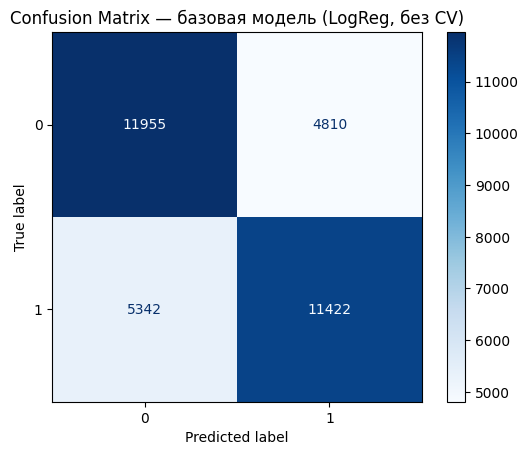

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

classification_model = LogisticRegression(max_iter=1000, solver="lbfgs")

# Pipeline («конвейер»): объединяем шаги в одну «трубу».
full_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),   # шаг 1: трансформация признаков (учится ТОЛЬКО на train)
        ("clf", classification_model)   # шаг 2: модель (учится на выходе из шага 1)
    ]
)

# Обучаемся на TRAIN, проверяемся на TEST

# .fit(): одновременно подгоняет трансформеры (скейлер и OHE) и обучает модель на преобразованных train-данных.
full_pipeline.fit(features_train, target_train)

# .predict(): применяет те же самые трансформации к test-данным и выдаёт предсказания классов.
test_predictions = full_pipeline.predict(features_test)

# Считаем базовые метрики качества:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Accuracy = доля верно предсказанных объектов
test_accuracy = accuracy_score(target_test, test_predictions)

# F1-macro = среднее F1 по всем классам (важно, если классы несбалансированы)
test_f1_macro = f1_score(target_test, test_predictions, average="macro")

print("\n=== БАЗОВЫЙ РЕЗУЛЬТАТ НА TEST ===")
print("Accuracy (test):", round(test_accuracy, 3))
print("F1-macro (test):", round(test_f1_macro, 3))

# Детальный отчёт по классам
print("\nОтчёт по классам (classification_report):\n")
print(classification_report(target_test, test_predictions, digits=3))

# Визуальный контроль: матрица ошибок (confusion matrix)
ConfusionMatrixDisplay.from_predictions(target_test, test_predictions, cmap="Blues")
plt.title("Confusion Matrix — базовая модель (LogReg, без CV)")
plt.show()

Мы получили неплохие результаты при обучении модели, точность получилась около 70%. Чуть точнее предсказывает (precisons) класс "1", а вот чувствительность (recall) для него хуже. Как результат, в целом модель лучше предсказывает (f1-score) результат для класса "0".


2. Модель kNN (5 ближайших соседей)


=== РЕЗУЛЬТАТЫ KNN ===
Accuracy (test): 0.723
F1-macro (test): 0.722

Отчёт по классам (classification_report):

              precision    recall  f1-score   support

           0      0.740     0.686     0.712     16765
           1      0.707     0.759     0.732     16764

    accuracy                          0.723     33529
   macro avg      0.724     0.723     0.722     33529
weighted avg      0.724     0.723     0.722     33529



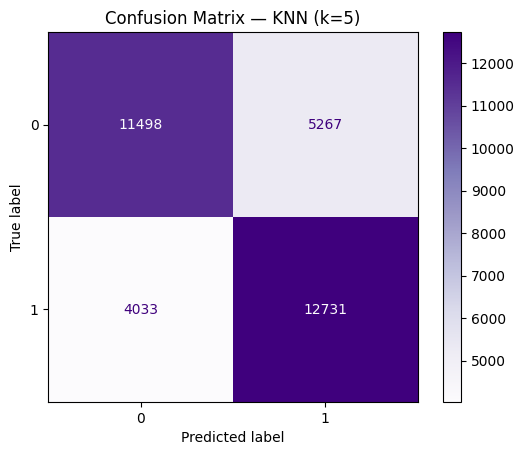

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Модель kNN с k=5
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
#knn_model7 = KNeighborsClassifier(n_neighbors=7)
#knn_model9 = KNeighborsClassifier(n_neighbors=9)

# Собираем тот же пайплайн (препроцессинг остаётся прежним)
knn_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", knn_model)
    ]
)

# Обучаем на train, проверяем на test
knn_pipeline.fit(features_train, target_train)
knn_predictions = knn_pipeline.predict(features_test)

# Метрики
knn_accuracy = accuracy_score(target_test, knn_predictions)
knn_f1_macro = f1_score(target_test, knn_predictions, average="macro")

print("\n=== РЕЗУЛЬТАТЫ KNN ===")
print("Accuracy (test):", round(knn_accuracy, 3))
print("F1-macro (test):", round(knn_f1_macro, 3))
print("\nОтчёт по классам (classification_report):\n")
print(classification_report(target_test, knn_predictions, digits=3))

# Матрица ошибок
ConfusionMatrixDisplay.from_predictions(target_test, knn_predictions, cmap="Purples")
plt.title("Confusion Matrix — KNN (k=5)")
plt.show()

Мы получили результаты лучше при обучении модели kNN, точность получилась около 73%. Для классов получили обратный результат, чуть точнее предсказывает (precisons) класс "0", а вот чувствительность (recall) для него хуже. Как результат, в целом модель лучше предсказывает (f1-score) результат для класса "1".


3. Модель Дерево решений (Decision Tree)


=== РЕЗУЛЬТАТЫ Tree ===
Accuracy (test): 0.72
F1-macro (test): 0.72

Отчёт по классам (classification_report):

              precision    recall  f1-score   support

           0      0.720     0.721     0.720     16765
           1      0.721     0.719     0.720     16764

    accuracy                          0.720     33529
   macro avg      0.720     0.720     0.720     33529
weighted avg      0.720     0.720     0.720     33529



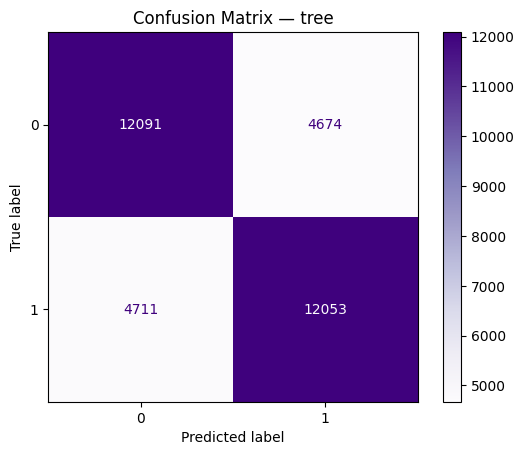

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Базовое дерево
dt_model = DecisionTreeClassifier(random_state=42)

# Собираем пайплайн (препроцессинг остаётся прежним)
dt_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", dt_model)  # используем дерево с глубиной 5
    ]
)

# Обучаем на train, проверяем на test
dt_pipeline.fit(features_train, target_train)
dt_predictions = dt_pipeline.predict(features_test)

# Метрики
dt_accuracy = accuracy_score(target_test, dt_predictions)
dt_f1_macro = f1_score(target_test, dt_predictions, average="macro")

print("\n=== РЕЗУЛЬТАТЫ Tree ===")
print("Accuracy (test):", round(dt_accuracy, 3))
print("F1-macro (test):", round(dt_f1_macro, 3))
print("\nОтчёт по классам (classification_report):\n")
print(classification_report(target_test, dt_predictions, digits=3))

# Матрица ошибок
ConfusionMatrixDisplay.from_predictions(target_test, dt_predictions, cmap="Purples")
plt.title("Confusion Matrix — tree")
plt.show()

Мы получили результаты чуть хуже, чем при обучении модели kNN, точность получилась около 72%. Для классов получили примерно одинаковый результат.

### Шаг 4. Сводная оценка качества моделей

In [14]:
from tabulate import tabulate

def colorize_values(row_data, row_values):
    colored_row = [row_data[0]]

    numeric_values = row_values[1:]
    best_value = max(numeric_values)
    worst_value = min(numeric_values)

    for i, value in enumerate(row_values[1:], 1):
        if value == best_value:
            # Зеленый для лучшего
            colored_row.append(f"\033[92m{value}\033[0m")
        elif value == worst_value:
            # Красный для худшего
            colored_row.append(f"\033[91m{value}\033[0m")
        else:
            colored_row.append(str(value))

    return colored_row

# Данные
data = [
    ["Accuracy", round(test_accuracy, 3), round(knn_accuracy, 3), round(dt_accuracy, 3)],
    ["F1-macro", round(test_f1_macro, 3), round(knn_f1_macro, 3), round(dt_f1_macro, 3)]
]

# Заголовки столбцов
headers = ["", "LogisticRegression", "KNeighborsClassifier", "DecisionTreeClassifier"]

colored_data = [colorize_values(row, row) for row in data]

# Вывод таблицы
print(tabulate(colored_data, headers=headers, tablefmt="grid"))

+----------+----------------------+------------------------+--------------------------+
|          |   LogisticRegression |   KNeighborsClassifier |   DecisionTreeClassifier |
+==========+======================+========================+==========================+
| Accuracy |                0.697 |                  0.723 |                     0.72 |
+----------+----------------------+------------------------+--------------------------+
| F1-macro |                0.697 |                  0.722 |                     0.72 |
+----------+----------------------+------------------------+--------------------------+


### Шаг 5. Эксперименты

Попробуем построить kNN модель с большим количеством соседей (7 и 9)


In [15]:
knn7_model = KNeighborsClassifier(n_neighbors=7)
knn9_model = KNeighborsClassifier(n_neighbors=9)

# Собираем тот же пайплайн (препроцессинг остаётся прежним)
knn7_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", knn7_model)
    ]
)

# Обучаем на train, проверяем на test
knn7_pipeline.fit(features_train, target_train)
knn7_predictions = knn7_pipeline.predict(features_test)

# Метрики
knn7_accuracy = accuracy_score(target_test, knn7_predictions)
knn7_f1_macro = f1_score(target_test, knn7_predictions, average="macro")

knn9_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", knn9_model)
    ]
)

# Обучаем на train, проверяем на test
knn9_pipeline.fit(features_train, target_train)
knn9_predictions = knn9_pipeline.predict(features_test)

# Метрики
knn9_accuracy = accuracy_score(target_test, knn9_predictions)
knn9_f1_macro = f1_score(target_test, knn9_predictions, average="macro")

print("\n=== РЕЗУЛЬТАТЫ KNN ===")
print("Accuracy (7):", round(knn7_accuracy, 3))
print("F1-macro (7):", round(knn7_f1_macro, 3))

print("Accuracy (9):", round(knn9_accuracy, 3))
print("F1-macro (9):", round(knn9_f1_macro, 3))

data = [
    ["Accuracy", round(knn_accuracy, 3), round(knn7_accuracy, 3), round(knn9_accuracy, 3)],
    ["F1-macro", round(knn_f1_macro, 3), round(knn7_f1_macro, 3), round(knn9_f1_macro, 3)]
]

# Заголовки столбцов
headers = ["", "KNeighborsClassifier (k=5)", "KNeighborsClassifier (k=7)", "KNeighborsClassifier (k=9)"]

colored_data = [colorize_values(row, row) for row in data]

# Вывод таблицы
print(tabulate(colored_data, headers=headers, tablefmt="grid"))


=== РЕЗУЛЬТАТЫ KNN ===
Accuracy (7): 0.723
F1-macro (7): 0.723
Accuracy (9): 0.724
F1-macro (9): 0.724
+----------+------------------------------+------------------------------+------------------------------+
|          |   KNeighborsClassifier (k=5) |   KNeighborsClassifier (k=7) |   KNeighborsClassifier (k=9) |
+==========+==============================+==============================+==============================+
| Accuracy |                        0.723 |                        0.723 |                        0.724 |
+----------+------------------------------+------------------------------+------------------------------+
| F1-macro |                        0.722 |                        0.723 |                        0.724 |
+----------+------------------------------+------------------------------+------------------------------+


Изменение параметров модели (количество соседей) дало незначительное улучшение

In [16]:
candidate_feature_columns = [
  "Vehicle_Reference_df_res",
  "Vehicle_Type",
  "Vehicle_Manoeuvre",
  "Vehicle_Location-Restricted_Lane",
  "Hit_Object_in_Carriageway",
  "Hit_Object_off_Carriageway",
  "Was_Vehicle_Left_Hand_Drive?",
  "Age_of_Driver",
  "Age_Band_of_Driver",
  "Engine_Capacity_(CC)",
  "Propulsion_Code",
  "Age_of_Vehicle",
  "Location_Easting_OSGR",
  "Location_Northing_OSGR",
  #"Longitude",
  #"Latitude",
  #"Police_Force",
  "Number_of_Vehicles",
  "Number_of_Casualties",
  #"Local_Authority_(District)",
  #"1st_Road_Number",
  #"2nd_Road_Number",
  #"Urban_or_Rural_Area",
  #"Vehicle_Reference_df",
  #"Casualty_Reference",
  "Sex_of_Casualty",
  "Age_of_Casualty",
  "Age_Band_of_Casualty",
  "Pedestrian_Location",
  "Pedestrian_Movement",
  "Casualty_Type",
  "Casualty_IMD_Decile",
]

# Объединим всё, что мы "ожидаем" увидеть:
expected_columns = set([target_column] + candidate_feature_columns)

# Проверим, что весь ожидаемый набор реально присутствует в данных.
missing_columns = expected_columns - all_columns_from_data
if missing_columns:
    # Если чего-то нет — падаем сразу с понятной ошибкой, а не через полчаса в моделях.
    raise ValueError(
        "В датасете не хватает ожидаемых колонок: "
        f"{sorted(missing_columns)}.\n"
        "Проверьте версию датасета/сплита или скорректируйте список признаков."
    )

# Если мы тут, значит всё на месте. Зафиксируем «ключевые» списки — они пригодятся дальше.
feature_columns = candidate_feature_columns[:]

prepared_dataframe = my_dataframe[feature_columns + [target_column]].copy()
mixed_dataframe = prepared_dataframe.sample(frac=1).reset_index(drop=True)

# Отделяем признаки (X) и целевую переменную (y).
features_matrix = prepared_dataframe[feature_columns].copy()
target_vector = prepared_dataframe[target_column].copy()


# Разбиваем на train/test
from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(
    features_matrix,       # все признаки (X)
    target_vector,         # целевая переменная (y)
    test_size=0.3,         # 30% в тестовую выборку, 70% в обучающую
    stratify=target_vector, # сохраняем баланс классов
    random_state=42        # фиксируем "случайность", чтобы у всех получился одинаковый split (Воспроизводимость экспериментов очень важна)
)

# Кодирование категориальных признаков
# Все признаки нашего датасета - числовые, кодирование не нужно
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

features_categorical_columns = (
    my_dataframe[feature_columns]
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

# Скейлинг
numeric_transformer = StandardScaler()

features_numeric_columns = (
    my_dataframe[feature_columns]
    .select_dtypes(include="number")
    .columns
    .tolist()
)

# Итоговый трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ("scale_numeric", numeric_transformer, features_numeric_columns),
        ("onehot_categorical", categorical_transformer, features_categorical_columns),
    ],
    remainder="drop"
)

transformed_train = preprocessor.fit_transform(features_train)  # обучили трансформеры на train и применили

final_feature_names = list(features_numeric_columns) #+ list(ohe_feature_names)

sample_rows = min(5, transformed_train.shape[0])
if hasattr(transformed_train, "toarray"):
    sample_array = transformed_train[:sample_rows].toarray()
else:
    sample_array = transformed_train[:sample_rows]
demo_transformed_df = pd.DataFrame(sample_array, columns=final_feature_names)

numeric_part = sample_array[:, :len(features_numeric_columns)]

from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Модель kNN с k=9
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=9)

# Собираем тот же пайплайн (препроцессинг остаётся прежним)
knn_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", knn_model)
    ]
)

# Обучаем на train, проверяем на test
knn_pipeline.fit(features_train, target_train)
knn_predictions = knn_pipeline.predict(features_test)

# Метрики
knn9m_accuracy = accuracy_score(target_test, knn_predictions)
knn9m_f1_macro = f1_score(target_test, knn_predictions, average="macro")

print("\n=== РЕЗУЛЬТАТЫ KNN ===")
print("Accuracy (test):", round(knn9m_accuracy, 3))
print("F1-macro (test):", round(knn9m_f1_macro, 3))
print("\nОтчёт по классам (classification_report):\n")
print(classification_report(target_test, knn_predictions, digits=3))

data = [
    ["Accuracy", round(knn_accuracy, 3), round(knn7_accuracy, 3), round(knn9_accuracy, 3), round(knn9m_accuracy, 3)],
    ["F1-macro", round(knn_f1_macro, 3), round(knn7_f1_macro, 3), round(knn9_f1_macro, 3), round(knn9m_f1_macro, 3)]
]

# Заголовки столбцов
headers = ["", "KNeighborsClassifier (k=5)", "KNeighborsClassifier (k=7)", "KNeighborsClassifier (k=9)", "KNeighborsClassifier (k=9, fixed)"]

colored_data = [colorize_values(row, row) for row in data]

# Вывод таблицы
print(tabulate(colored_data, headers=headers, tablefmt="grid"))


=== РЕЗУЛЬТАТЫ KNN ===
Accuracy (test): 0.73
F1-macro (test): 0.73

Отчёт по классам (classification_report):

              precision    recall  f1-score   support

           0      0.748     0.695     0.720     16765
           1      0.715     0.765     0.739     16764

    accuracy                          0.730     33529
   macro avg      0.731     0.730     0.730     33529
weighted avg      0.731     0.730     0.730     33529

+----------+------------------------------+------------------------------+------------------------------+-------------------------------------+
|          |   KNeighborsClassifier (k=5) |   KNeighborsClassifier (k=7) |   KNeighborsClassifier (k=9) |   KNeighborsClassifier (k=9, fixed) |
+==========+==============================+==============================+==============================+=====================================+
| Accuracy |                        0.723 |                        0.723 |                        0.724 |                        

Исключение невлияющих (на основе экспертной оценка) параметров улучшило качество модели

Добавим кросс-валидацию. Попробуем также перемешать данные (shuffle).

In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Создаем пайплайн (как у вас, но без предварительного split)
pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", KNeighborsClassifier(n_neighbors=9))
    ]
)

# Настраиваем кросс-валидацию
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Проводим 5-кратную кросс-валидацию
cv_scores_accuracy = cross_val_score(
    pipeline,
    features_matrix,  # все данные (X)
    target_vector,    # все данные (y)
    cv=cv_strategy,
    scoring='accuracy'
)

cv_scores_f1 = cross_val_score(
    pipeline,
    features_matrix,
    target_vector,
    cv=cv_strategy,
    scoring='f1_macro'
)

print("=== РЕЗУЛЬТАТЫ 5-FOLD КРОСС-ВАЛИДАЦИИ (k=9) ===")
print(f"Accuracy: {cv_scores_accuracy.mean():.3f} (+/- {cv_scores_accuracy.std() * 2:.3f})")
print(f"F1-macro: {cv_scores_f1.mean():.3f} (+/- {cv_scores_f1.std() * 2:.3f})")
print(f"\nЗначения по фолдам:")
print(f"Accuracy по фолдам: {[round(x, 3) for x in cv_scores_accuracy]}")
print(f"F1-macro по фолдам: {[round(x, 3) for x in cv_scores_f1]}")

=== РЕЗУЛЬТАТЫ 5-FOLD КРОСС-ВАЛИДАЦИИ (k=9) ===
Accuracy: 0.736 (+/- 0.004)
F1-macro: 0.735 (+/- 0.004)

Значения по фолдам:
Accuracy по фолдам: [np.float64(0.734), np.float64(0.737), np.float64(0.739), np.float64(0.734), np.float64(0.734)]
F1-macro по фолдам: [np.float64(0.734), np.float64(0.736), np.float64(0.739), np.float64(0.733), np.float64(0.734)]


### Шаг 6. Итог

1. Для выбранного датасета лучшая модель - kNN с k=9 (на 3% точнее, чем худшая модель).
2. Исключение признаков, не связанных с целевым параметром (информация о локации аварии), улучшило модель.
3. Модель "Дерево решений" показала равномерные результаты для обоих классов.
4. Кросс-валидация и перемешивание данных дают прирост на 1%.